Parte 1. Carga y Exploracion de datos 

In [1]:

import pandas as pd 
import matplotlib.pyplot as plt
import math
import random
import numpy as np

Cargamos el CVS con pd.read_csv

In [2]:
df = pd.read_csv("proyecto_final_pacientes_biomedicos.csv")

#Mostrar las primeras filas del DataFrame
##.head muestra las primeras filas del DataFrame, lo que nos permite tener una idea de cómo están organizados los datos y qué tipo de información contienen
print(df.head())

  id_paciente  edad sexo    grupo_clinico  fc_lpm  ruido_ecg estado_eeg  \
0        P001    21    F  control_estable      64      0.018   relajado   
1        P002    24    M  control_estable      68      0.020   relajado   
2        P003    27    F  control_estable      72      0.018     alerta   
3        P004    29    M  control_estable      75      0.022     alerta   
4        P005    31    F  control_estable      61      0.015   relajado   

   ruido_eeg  factor_contraccion  pa_sistolica  pa_diastolica  spo2_media  \
0      0.040                0.22           112             72        98.7   
1      0.045                0.28           118             76        98.3   
2      0.040                0.30           120             78        97.9   
3      0.050                0.35           122             80        98.1   
4      0.035                0.18           110             70        99.0   

   duracion_segundos prioridad  \
0                 10      baja   
1                 

In [3]:
#Mostrar dimensiones de la tabla 
## .shape nos permite conocer las dimesiones del data, numeros de fila y columnas 

df.shape


(24, 15)

In [4]:
#Tipos de datos de cada columna
## .dtypes nos ayuda a identificar el tipo de datos que tiene cada columna

df.dtypes

id_paciente               str
edad                    int64
sexo                      str
grupo_clinico             str
fc_lpm                  int64
ruido_ecg             float64
estado_eeg                str
ruido_eeg             float64
factor_contraccion    float64
pa_sistolica            int64
pa_diastolica           int64
spo2_media            float64
duracion_segundos       int64
prioridad                 str
nota_clinica              str
dtype: object

In [5]:
#Conteo de pacientes por Grupo clinico 
## .value_counts nos perimte contar la frecuencia de cada valor unico en la columna
df['grupo_clinico'].value_counts()


grupo_clinico
control_estable       6
taquicardia_estres    6
hipertension          6
hipoxemia_fatiga      6
Name: count, dtype: int64

In [6]:
#Verificar si hay valores faltantes 
## .isna nos identifica los valores faltantes mientras que el .sum nos dice el numero de valores que faltan por cada columna
df.isna().sum()

id_paciente           0
edad                  0
sexo                  0
grupo_clinico         0
fc_lpm                0
ruido_ecg             0
estado_eeg            0
ruido_eeg             0
factor_contraccion    0
pa_sistolica          0
pa_diastolica         0
spo2_media            0
duracion_segundos     0
prioridad             0
nota_clinica          0
dtype: int64

Parte 2. Preparacion de la base con pandas

In [7]:
#Columna de pulso de presion 
df['pulso_presion'] = df['pa_sistolica'] - df['pa_diastolica']

#Columna de Hipoxemia (spo2_media < 92)
df['hipoxemia'] = df['spo2_media'] < 92

#Columna de hipertension (sistolica >= 140 o diastolica >= 90)
df['hipertencion'] = (df['pa_sistolica'] >= 140) | (df['pa_diastolica'] >= 90)

#Columna de taquicardia (fc_lpm > 100)
df['taquicardia'] = df['fc_lpm'] > 100


In [8]:
#visualizar columnas agregadas 
df.head()

,id_paciente,edad,sexo,grupo_clinico,fc_lpm,ruido_ecg,estado_eeg,ruido_eeg,factor_contraccion,pa_sistolica,pa_diastolica,spo2_media,duracion_segundos,prioridad,nota_clinica,pulso_presion,hipoxemia,hipertencion,taquicardia
0,P001,21,F,control_estable,64,0.018,relajado,0.040,0.22,112,72,98.7,10,baja,Paciente de referencia sin alteraciones clinicas.,40,False,False,False
1,P002,24,M,control_estable,68,0.020,relajado,0.045,0.28,118,76,98.3,10,baja,Perfil fisiologico normal con senales estables.,42,False,False,False
2,P003,27,F,control_estable,72,0.018,alerta,0.040,0.30,120,78,97.9,10,baja,Paciente sano en actividad ligera.,42,False,False,False
3,P004,29,M,control_estable,75,0.022,alerta,0.050,0.35,122,80,98.1,12,baja,Frecuencia cardiaca normal alta con buena oxig...,42,False,False,False
4,P005,31,F,control_estable,61,0.015,relajado,0.035,0.18,110,70,99.0,10,baja,Paciente en reposo con presion arterial normal.,40,False,False,False


Preguntas preparacion de la base con pandas 

In [9]:
#.sum contara los true por los datos boleanos 
#1. ¿Cuantos pacientes tienen hipoxemia?.
total_hipoxemia = df['hipoxemia'].sum()
print(f"1.Total de pacientes con hipoxemia es:{total_hipoxemia}")


#2. ¿Cuantos pacientes tienen taquicardia?.
total_taquicardia = df['taquicardia'].sum()
print(f"2.Total de pacientes con taquicardia es:{total_taquicardia}")

#3. ¿Cual grupo presenta mayor presion sistolica promedio?.
presion_sistolica_promedio = df.groupby('grupo_clinico')['pa_sistolica'].mean()
print("3. Presion sistolica promedio por grupo clinico:")
print(presion_sistolica_promedio)


1.Total de pacientes con hipoxemia es:5
2.Total de pacientes con taquicardia es:10
3. Presion sistolica promedio por grupo clinico:
grupo_clinico
control_estable       117.666667
hipertension          161.333333
hipoxemia_fatiga      125.000000
taquicardia_estres    136.166667
Name: pa_sistolica, dtype: float64


 Parte 3. Reutilizacion de funciones del notebook 00

In [10]:
#Funcion para modelar ondas cardiacas 
def gaussiana(t, amplitud , centro, ancho):
    return amplitud * np.exp(-((t - centro) ** 2) / (2 * ancho ** 2))

In [11]:
#Funcion nivel de contraccion 
def nivel_contraccion(t, contraccion=0.5, fs=2000):
    amplitud = contraccion * 2.0  
    señal = random.gauss(0, amplitud)
    
    # Componente de baja frecuencia (artefacto de movimiento)
    
    señal += 0.1 * math.sin(2 * math.pi * 3 * t)
    return señal


In [12]:
#Adaptar el EMG sintetico para incluir el nivel de contraccion
def emg_sintetico(t, contraccion=1.0):
    # Simular un EMG con ruido y variabilidad
    frecuencia_base = 10  # Frecuencia base del EMG
    ruido = np.random.normal(0, 0.1, size=t.shape)  # Ruido aleatorio
    emg = contraccion * np.sin(2 * np.pi * frecuencia_base * t) + ruido
    return emg

In [13]:
#Funcion para EEG sintetico
def eeg_sintetico(t, estado="relajado", ruido=0.05):
    pi2 = 2 * math.pi

    amplitudes = {
        "sueño": {"delta":1.5,"theta":0.5,"alfa":0.2,"beta":0.05},
        "relajado": {"delta":0.3,"theta":0.4,"alfa":1.0,"beta":0.3},
        "alerta": {"delta":0.1,"theta":0.2,"alfa":0.3,"beta":0.8},
        "concentrado": {"delta":0.1,"theta":0.1,"alfa":0.1,"beta":1.2},
    }

    amp = amplitudes.get(estado, amplitudes["relajado"])

    señal = (
        amp["delta"] * np.sin(pi2 * 2 * t) +
        amp["theta"] * np.sin(pi2 * 6 * t) +
        amp["alfa"]  * np.sin(pi2 * 10 * t) +
        amp["beta"]  * np.sin(pi2 * 20 * t)
    )

    señal += np.random.normal(0, ruido, size=t.shape)
    return señal * 50


In [14]:
#Funcion para ECG sintetico
def ecg_sintetico(t, fc=72, ruido=0.02):
    periodo = 60.0 / fc       # duración de un ciclo cardíaco [s]
    t_ciclo = (t % periodo) / periodo   # posición normalizada [0, 1] en el ciclo

    señal = 0.0
    # Onda P (despolarización auricular)
    señal += gaussiana(t_ciclo, 0.15, 0.18, 0.025)
    # Onda Q (inicio de despolarización ventricular — negativa)
    señal -= gaussiana(t_ciclo, 0.10, 0.42, 0.010)
    # Onda R (despolarización ventricular — pico principal)
    señal += gaussiana(t_ciclo, 1.00, 0.46, 0.008)
    # Onda S (despolarización septal — negativa)
    señal -= gaussiana(t_ciclo, 0.22, 0.50, 0.008)
    # Onda T (repolarización ventricular)
    señal += gaussiana(t_ciclo, 0.30, 0.68, 0.035)

    # Ruido fisiológico 
    señal += random.gauss(0, ruido)
    return señal

In [15]:
#Funcion para modelar presion arterial
def presion_arterial(t, sistolica = 120, diastolica =80, fc= 72):
    periodo = 60.0 / fc
    t_norm = (t % periodo) / periodo
    
    # Pico sistólico
    pico = (sistolica - diastolica) * gaussiana(t_norm, 1.0, 0.25, 0.08)
    # Muesca dicrota (rebote de la válvula aórtica)
    muesca = (sistolica - diastolica) * 0.15 * gaussiana(t_norm, 1.0, 0.55, 0.04)
    
    return diastolica + pico + muesca + random.gauss(0, 0.5)


In [16]:
#Funcion para modelar Sp02 
def spo2_ppg(t, spo2_media=98.5, fc=72):
    periodo = 60.0 / fc
    variacion = 0.5 * np.sin(2 * np.pi * t / periodo)
    modulacion = 0.3 * np.sin(2 * np.pi * 0.25 * t)
    return spo2_media + variacion + modulacion + np.random.normal(0,0.1,size=t.shape)


In [17]:
def t_vector(tiempo_total=10, fs=2000):
    return np.linspace(0, tiempo_total, int(tiempo_total * fs), endpoint=False) 

Parte 4. Generacion de senales por paciente

In [18]:
def generar_senales_paciente(fila):

    t = t_vector(fila["duracion_segundos"], 500)

    # ECG
    sig_ecg = ecg_sintetico(t, fc=fila['fc_lpm'], ruido=fila['ruido_ecg'])

    # EEG
    sig_eeg = eeg_sintetico(
        t,
        estado=fila['estado_eeg'],
        ruido=fila['ruido_eeg']
    )

    # EMG usando nivel_contraccion
    contraccion = np.array([
        min(1.0, fila["factor_contraccion"] * nivel_contraccion(ti))
        for ti in t
    ])
    sig_emg = emg_sintetico(t, contraccion=contraccion)

    # Presión arterial
    sig_pa = presion_arterial(
        t,
        sistolica=fila['pa_sistolica'],
        diastolica=fila['pa_diastolica'],
        fc=fila['fc_lpm']
    )

    # SpO2
    sig_spo2 = spo2_ppg(
        t,
        spo2_media=fila['spo2_media'],
        fc=fila['fc_lpm']
    )

    return pd.DataFrame({
        'tiempo_s': t,
        'ecg_mV': sig_ecg,
        'eeg_uV': sig_eeg,
        'emg_mV': sig_emg,
        'pa_mmHg': sig_pa,
        'spo2_pct': sig_spo2
    })

In [19]:
fila_paciente = df.iloc[0]

# Generamos el DataFrame de señales
df_senales_final = generar_senales_paciente(fila_paciente)

# Mostrar resultado
df_senales_final.head()

,tiempo_s,ecg_mV,eeg_uV,emg_mV,pa_mmHg,spo2_pct
0,0.000,0.008225,2.495349,0.089442,72.269555,98.691813
1,0.002,0.008225,14.372198,0.150058,72.295772,98.740106
2,0.004,0.008225,21.697038,0.201765,72.324003,98.866509
3,0.006,0.008225,37.786644,0.031390,72.354379,98.796488
4,0.008,0.008225,42.450209,0.014711,72.387037,98.726417


In [20]:
paciente_data = df.iloc[0]  # Tomamos la fila del primer paciente
df_senales_p1 = generar_senales_paciente(paciente_data)

# Visualizamos el resultado
df_senales_p1.head()

,tiempo_s,ecg_mV,eeg_uV,emg_mV,pa_mmHg,spo2_pct
0,0.000,0.025341,2.192951,0.102722,71.907974,98.819397
1,0.002,0.025341,9.254124,-0.096512,71.934191,98.760917
2,0.004,0.025341,23.436016,0.011053,71.962422,98.634490
3,0.006,0.025341,35.809435,0.062831,71.992798,98.801096
4,0.008,0.025341,47.133799,-0.068879,72.025456,98.799271


## 5-Pacientes a analizar

In [ ]:
# Seleccionar pacientes por grupo
def obtener_paciente(df, grupo):
    subset = df[df['grupo_clinico'] == grupo]
    if subset.empty:
        print(f"No hay datos para el grupo: {grupo}")
        return None
    #Return subset.iloc[0] nos devuelve el primer paciente del grupo clinico encontrado, lo que nos permite generar señales para ese paciente específico
    return subset.iloc[0]

In [22]:
#Obtenemos los datos de los pacientes dependiendo de su grupo
pac_control = obtener_paciente(df, 'control_estable')
pac_taquicardia = obtener_paciente(df, 'taquicardia_estres')
pac_hipertension = obtener_paciente(df, 'hipertension')
pac_hipoxemia = obtener_paciente(df, 'hipoxemia_fatiga')

In [23]:
# Generar señales de los pacientes seleccionados dependiendo de su grupo clinico
sen_control = generar_senales_paciente(pac_control)
sen_taq = generar_senales_paciente(pac_taquicardia)
sen_hipert = generar_senales_paciente(pac_hipertension)
sen_hipox = generar_senales_paciente(pac_hipoxemia)

## 6- Analisis

In [24]:
# Tabla de resumen de los datos por grupo clínico
df_resumen = df.groupby('grupo_clinico').agg({
    'fc_lpm': 'mean',
    'spo2_media': 'mean',
    'pa_sistolica': 'mean',
    'pa_diastolica': 'mean'
})

print("Resumen por grupo:")
df_resumen.head()


Resumen por grupo:


,fc_lpm,spo2_media,pa_sistolica,pa_diastolica
grupo_clinico,,,,
control_estable,69.666667,98.266667,117.666667,76.333333
hipertension,85.166667,96.150000,161.333333,101.000000
hipoxemia_fatiga,104.000000,90.383333,125.000000,81.000000
taquicardia_estres,116.833333,96.500000,136.166667,87.000000


In [25]:
#Detecta pacientes con valores extremos
mayor_fc = df.loc[df['fc_lpm'].idxmax()]
menor_spo2 = df.loc[df['spo2_media'].idxmin()]
mayor_pulso = df.loc[df['pulso_presion'].idxmax()]

#Imprime los datos de los pacientes
print("\nMayor FC:")
print(mayor_fc)

print("\nMenor SpO2:")
print(menor_spo2)

print("\nMayor pulso de presión:")
print(mayor_pulso)


Mayor FC:
id_paciente                                            P012
edad                                                     33
sexo                                                      M
grupo_clinico                            taquicardia_estres
fc_lpm                                                  132
ruido_ecg                                             0.048
estado_eeg                                      concentrado
ruido_eeg                                             0.075
factor_contraccion                                     0.88
pa_sistolica                                            145
pa_diastolica                                            92
spo2_media                                             95.6
duracion_segundos                                        12
prioridad                                              alta
nota_clinica          Paciente con carga simpatica elevada.
pulso_presion                                            53
hipoxemia                    

## 7- Generación de las graficas

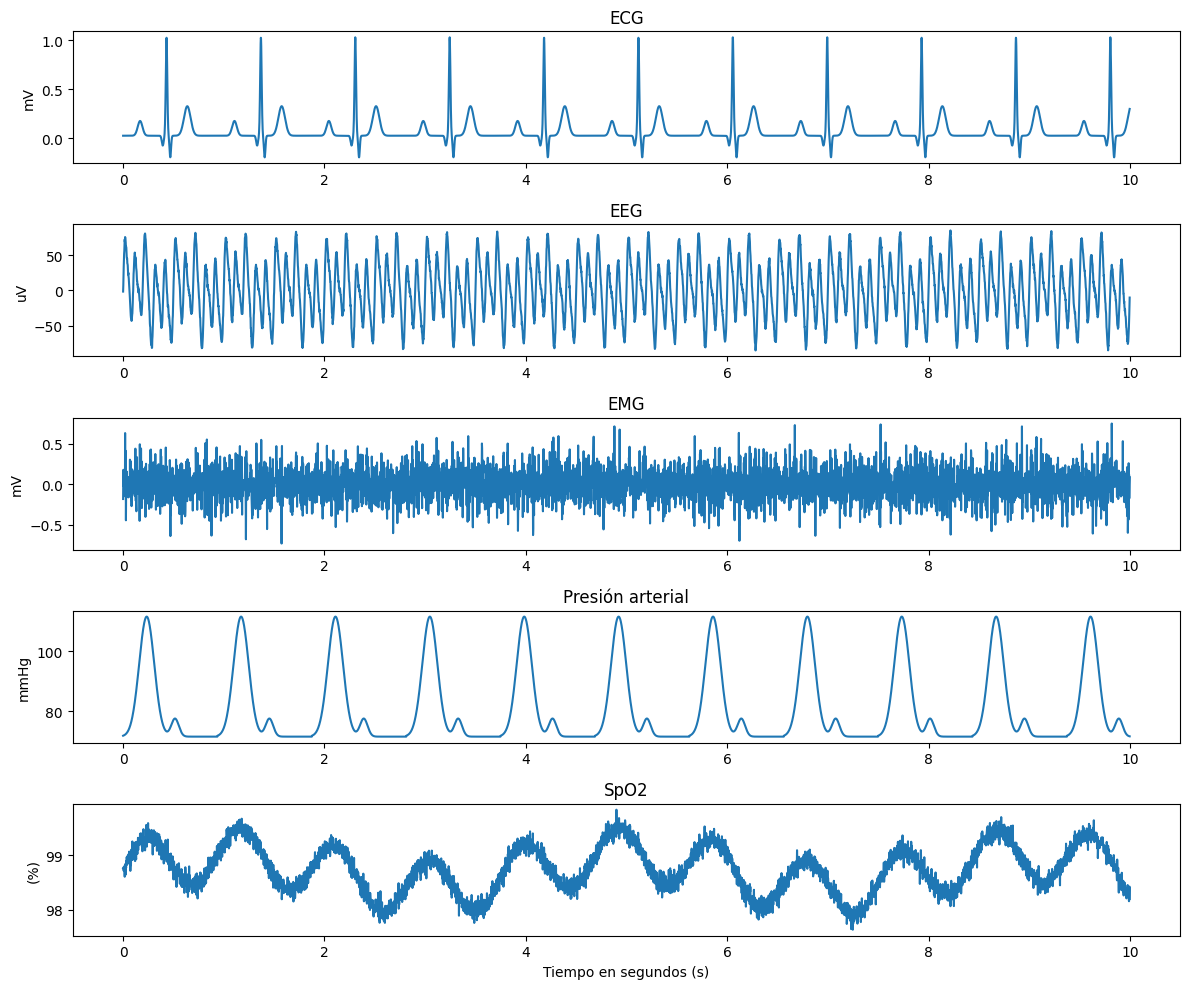

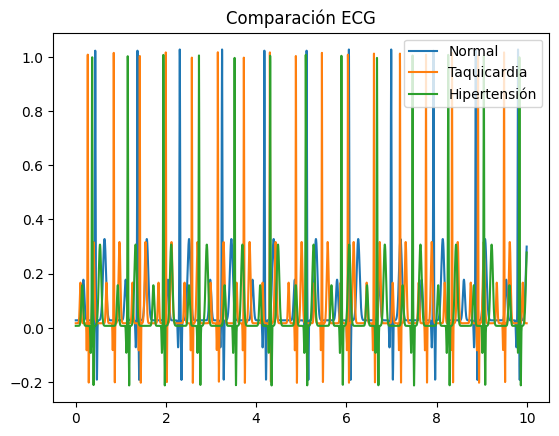

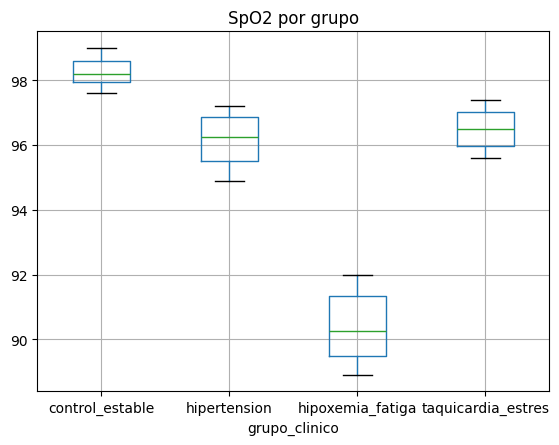

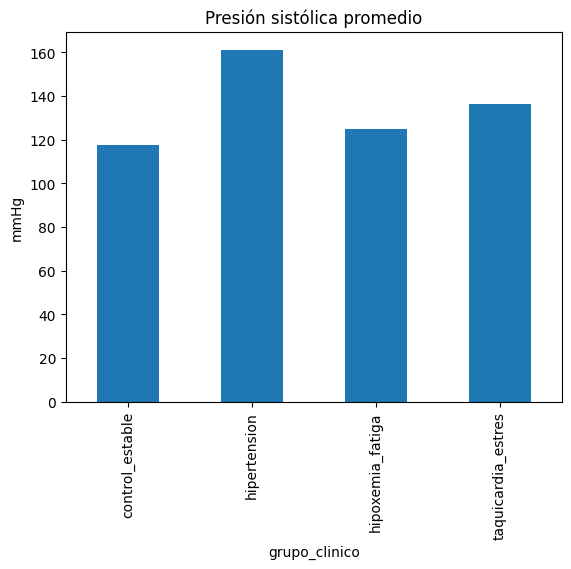

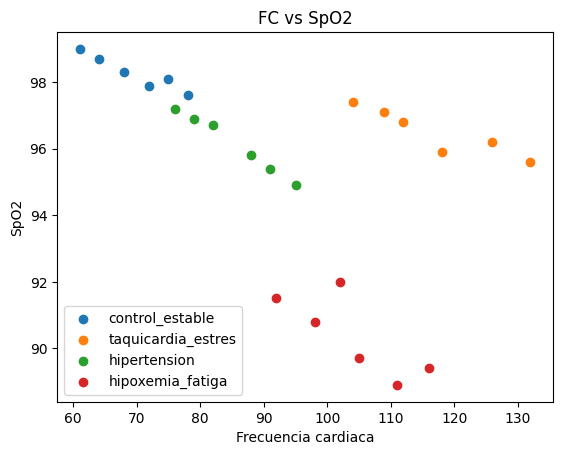

In [26]:
#Generación de graficas


#Grafica de señales ECG, EEG, EMG, Presion arterial y SpO2 para el paciente control
plt.figure(figsize=(12,10))

plt.subplot(5,1,1)
plt.plot(sen_control['tiempo_s'], sen_control['ecg_mV'])
plt.title("ECG")
plt.ylabel("mV")

plt.subplot(5,1,2)
plt.plot(sen_control['tiempo_s'], sen_control['eeg_uV'])
plt.title("EEG")
plt.ylabel("uV")

plt.subplot(5,1,3)
plt.plot(sen_control['tiempo_s'], sen_control['emg_mV'])
plt.title("EMG")
plt.ylabel("mV")

plt.subplot(5,1,4)
plt.plot(sen_control['tiempo_s'], sen_control['pa_mmHg'])
plt.title("Presión arterial")
plt.ylabel("mmHg")
plt.subplot(5,1,5)
plt.plot(sen_control['tiempo_s'], sen_control['spo2_pct'])
plt.title("SpO2")
plt.ylabel("(%)")

plt.xlabel("Tiempo en segundos (s)")
plt.tight_layout()
plt.show()

#Se crea la gráfica comparativa de ECG entre los grupos clínicos

plt.figure()

plt.plot(sen_control['tiempo_s'], sen_control['ecg_mV'], label="Normal")
plt.plot(sen_taq['tiempo_s'], sen_taq['ecg_mV'], label="Taquicardia")
plt.plot(sen_hipert['tiempo_s'], sen_hipert['ecg_mV'], label="Hipertensión")

plt.legend()
plt.title("Comparación ECG")
plt.show()

#Se crea la gráfica de boxplot para comparar SpO2 entre los grupos clínicos
df.boxplot(column='spo2_media', by='grupo_clinico')
plt.title("SpO2 por grupo")
plt.suptitle("")
plt.show()

#Se crea la gráfica de barras para comparar la presión sistólica promedio entre los grupos clínicos
df.groupby('grupo_clinico')['pa_sistolica'].mean().plot(kind='bar')
plt.title("Presión sistólica promedio")
plt.ylabel("mmHg")
plt.show()


#Se crea la gráfica de dispersión para comparar la relación entre frecuencia cardiaca y SpO2, diferenciando por grupo clínico
for grupo in df['grupo_clinico'].unique():
    subset = df[df['grupo_clinico'] == grupo]
    plt.scatter(subset['fc_lpm'], subset['spo2_media'], label=grupo)

plt.xlabel("Frecuencia cardiaca")
plt.ylabel("SpO2")
plt.legend()
plt.title("FC vs SpO2")
plt.show()

## 8-Conclusiones

1. Que grupo presenta mayor riesgo cardiovascular y por que.

El grupo con mayor riesgo cardiovascular es hipertension, ya que presenta valores elevados de presión arterial sistólica y diastólica, lo que incrementa el riesgo de eventos cardiovasculares.

2. Que diferencia observan entre un ECG normal y uno con taquicardia.

En un ECG con taquicardia se observa una mayor frecuencia de los complejos QRS, es decir, los latidos están más juntos en comparación con un ECG normal.

3. Como cambia el EEG entre `relajado`, `alerta` y `concentrado`.

El EEG cambia dependiendo del estado: en relajación predominan ondas alfa, en alerta aumentan las beta y en concentración se incrementan aún más las beta.

4. Que relacion encuentran entre `fc_lpm` y `spo2_media`.

Se observa que a mayor frecuencia cardiaca, en algunos casos la SpO2 puede disminuir ligeramente, especialmente en condiciones de estrés o fatiga.

5. Que limitaciones tiene trabajar con datos simulados en lugar de datos reales.

Una limitación de los datos simulados es que no representan completamente la variabilidad biológica real, por lo que los resultados pueden no reflejar condiciones clínicas reales con total precisión.